In [ ]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision.utils import make_grid
from torchvision.datasets import ImageFolder
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn.functional as F

In [ ]:
import warnings
warnings.filterwarnings('ignore')

In [ ]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
torch.cuda.device_count()

1

In [ ]:
def display_images(image_paths, title, max_images=4):
    plt.figure(figsize=(12, 3))
    for i, image_path in enumerate(image_paths[:max_images]):
        img = plt.imread(image_path)
        plt.subplot(1, max_images, i+1)
        plt.title(title)
        plt.axis('off')
        plt.imshow(img, cmap='gray')

    plt.show()

In [ ]:
categories = ['Train compress', 'Train defocus', 'Train general', 'Train motion', 'Train noise',
              'Val compress', 'Val defocus', 'Val general', 'Val motion', 'Val noise',
              'Test compress', 'Test defocus', 'Test general', 'Test motion', 'Test noise']

for category in categories:
    img_paths = glob.glob(f'/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Datasets/12-01. (1) 영상 품질 저하 요소 분류 실습 (Environmental Degradation 요소 및 tensorRT) - 데이터셋/{category.lower().replace(" ", "/")}/*')
    display_images(img_paths, category)
    print(f'Image count: {len(img_paths)}')

Output hidden; open in https://colab.research.google.com to view.

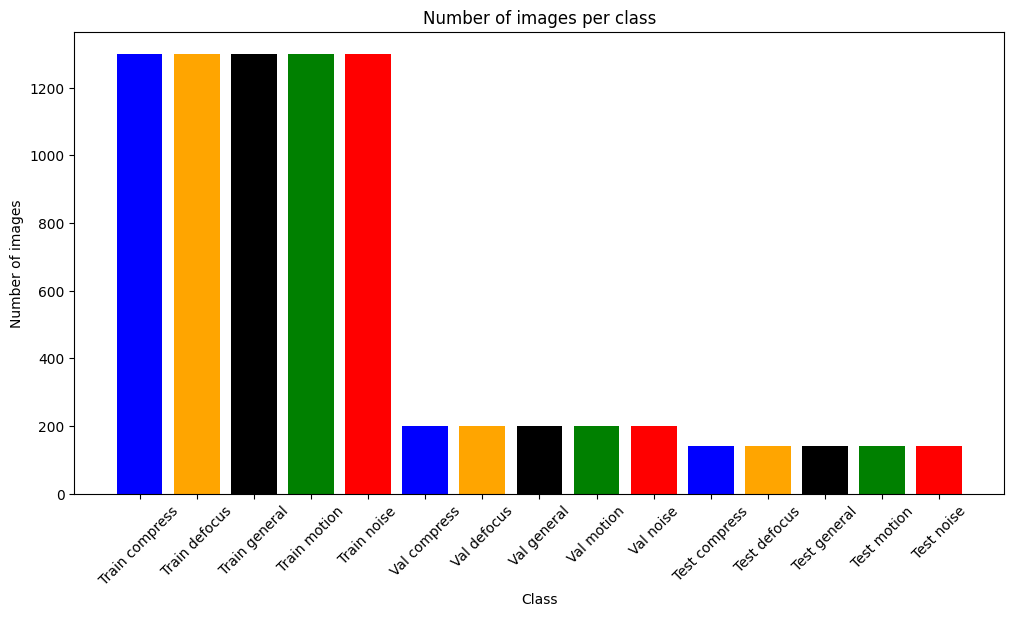

In [ ]:
plt.figure(figsize=(12, 6))
count = [len(glob.glob(f'/content/drive/MyDrive/Colab Notebooks/Fast Campus Image Processing/Datasets/12-01. (1) 영상 품질 저하 요소 분류 실습 (Environmental Degradation 요소 및 tensorRT) - 데이터셋/{category.lower().replace(" ", "/")}/*')) for category in categories]
plt.bar(categories, count, color=['blue', 'orange', 'black', 'green', 'red'])
plt.title("Number of images per class")
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.xticks(rotation=45)
plt.show()


In [ ]:
from imgaug import augmenters as iaa
import imgaug as ia

class ImgAugTranform:
    def __init__(self):
        self.aug = iaa.Sequential([
            iaa.Fliplr(0.5),
            iaa.Flipud(0.5),
            iaa.Sometimes(0.2, iaa.Affine(rotate=(-25, 25))),
            iaa.Sometimes(0.2, iaa.Multiply((0.8, 1.2)))
        ])

    def __call__(self, img):
        img = np.array(img)

        return self.aug.augment_image(img)